In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/tweets-and-user-engagement")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tweets-and-user-engagement' dataset.
Path to dataset files: /kaggle/input/tweets-and-user-engagement


### Exploring the Kaggle Dataset: `tweets-and-user-engagement`

Now that the Kaggle dataset has been downloaded, let's load it into a pandas DataFrame and perform an initial exploration. We need to identify the main CSV file within the downloaded directory and inspect its structure, columns, and a sample of its content. This will be crucial for adapting our existing analysis workflows, such as feature engineering and engagement scoring, to this new dataset.

In [2]:
import os
import pandas as pd

# List files in the downloaded Kaggle dataset path
print(f"Files in Kaggle dataset directory: {os.listdir(path)}")

# Assuming there's a main CSV file, let's try to load 'tweets.csv'
# This might need adjustment based on the actual file names in the directory.
kaggle_csv_path = os.path.join(path, 'Twitterdatainsheets.csv') # Corrected file name

try:
    kaggle_df = pd.read_csv(kaggle_csv_path)

    print('\nKaggle DataFrame Info:')
    kaggle_df.info()

    print('\nSample from the Kaggle DataFrame:')
    display(kaggle_df.head())

except FileNotFoundError:
    print(f"Error: '{kaggle_csv_path}' not found. Please check the file name in the Kaggle dataset.")
except Exception as e:
    print(f"An error occurred while loading or processing the Kaggle dataset: {e}")

Files in Kaggle dataset directory: ['Twitterdatainsheets.csv']


/tmp/ipykernel_34664/118740440.py:12: DtypeWarning: Columns (3,4,5,6,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  kaggle_df = pd.read_csv(kaggle_csv_path)



Kaggle DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206295 entries, 0 to 206294
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   index          206295 non-null  int64  
 1   TweetID        206291 non-null  object 
 2    Weekday       206292 non-null  object 
 3    Hour          106175 non-null  object 
 4    Day           106181 non-null  object 
 5    Lang          106133 non-null  object 
 6    IsReshare     100000 non-null  object 
 7    Reach         100000 non-null  float64
 8    RetweetCount  100000 non-null  float64
 9    Likes         100000 non-null  float64
 10   Klout         100000 non-null  float64
 11   Sentiment     100000 non-null  float64
 12   text          100000 non-null  object 
 13   LocationID    100000 non-null  float64
 14   UserID        100000 non-null  object 
dtypes: float64(6), int64(1), object(8)
memory usage: 23.6+ MB

Sample from the Kaggle DataFrame:


,index,TweetID,Weekday,Hour,Day,Lang,IsReshare,Reach,RetweetCount,Likes,Klout,Sentiment,text,LocationID,UserID
0,0,tw-682712873332805633,Thursday,17,31,en,False,44.0,0.0,0.0,35.0,0.0,We are hiring: Senior Software Engineer - Prot...,3751.0,tw-40932430
1,1,tw-682713045357998080,Thursday,17,31,en,True,1810.0,5.0,0.0,53.0,2.0,RT @CodeMineStatus: This is true Amazon Web Se...,3989.0,tw-3179389829
2,2,tw-682713219375476736,Thursday,17,31,en,False,282.0,0.0,0.0,47.0,0.0,Devops Engineer Aws Ansible Cassandra Mysql Ub...,3741.0,tw-4624808414
3,3,tw-682713436967579648,Thursday,17,31,en,False,2087.0,4.0,0.0,53.0,0.0,Happy New Year to all those AWS instances of o...,3753.0,tw-356447127
4,4,tw-682714048199311366,Thursday,17,31,en,False,953.0,0.0,0.0,47.0,0.0,Amazon is hiring! #Sr. #International Tax Mana...,3751.0,tw-3172686669


## Preparing Kaggle Data for XGBoost Engagement Predictor

To build the XGBoost engagement predictor for the Kaggle dataset, we need to follow similar data preparation steps as before, adapting them to the new dataset's structure. This involves:

1.  **Data Cleaning and Type Conversion**: Handle missing values and convert columns like `Weekday`, `Hour`, and `Day` to appropriate data types.
2.  **Create a Combined Engagement Score**: Normalize and sum individual engagement metrics (`RetweetCount`, `Likes`, `Reach`) to create a single target variable.
3.  **Log-Transform Engagement Score**: Apply a log transformation (`log1p`) to the combined engagement score.
4.  **Feature Engineering**: Extract and prepare features, converting categorical features (like time-based ones) into a numerical format suitable for XGBoost using one-hot encoding.
5.  **Chronological Train/Test Split**: Sort the data chronologically and split it into training and testing sets.

#### 1. Data Cleaning and Type Conversion

In [3]:
import numpy as np

# Make a copy to avoid modifying the original DataFrame directly
kaggle_df_processed = kaggle_df.copy()

# Rename columns to be more consistent and strip leading/trailing spaces from names
kaggle_df_processed.columns = kaggle_df_processed.columns.str.strip()
kaggle_df_processed = kaggle_df_processed.rename(columns={
    'Weekday': 'day_of_week_posted',
    'Hour': 'hour_posted',
    'RetweetCount': 'reposts',
    'Likes': 'likes'
})

# Convert 'day_of_week_posted' and 'hour_posted' to appropriate types
# Handle mixed types by coercing errors, then filling NaNs if needed.
kaggle_df_processed['hour_posted'] = pd.to_numeric(kaggle_df_processed['hour_posted'], errors='coerce')
kaggle_df_processed['day_of_week_posted'] = kaggle_df_processed['day_of_week_posted'].astype('category')

# The 'Day' column could be used to reconstruct a full date, but its type is mixed and has many NaNs.
# For now, we will rely on 'day_of_week_posted' and 'hour_posted'.
# If a 'date_posted' column can be reliably constructed, we'll do so for chronological split.
# Let's inspect the original 'Day' column and if it's usable for a date.

# Combine 'Day', 'hour_posted' and 'day_of_week_posted' to create a dummy 'date_posted' for chronological split.
# Since original dates are not available, we can synthesize one based on Day/Hour/Weekday.
# This is a placeholder for chronological sorting, as actual dates are not directly available and 'Day' is problematic.
# If 'Day' is an integer representing day of month, and 'hour_posted' is available.

# Let's check unique values in 'Day' column to see if it's consistent for date creation
# print(kaggle_df_processed['Day'].value_counts(dropna=False).head())

# Given the mixed types and high NaN count in 'Day' and 'Lang', we'll focus on 'hour_posted' and 'day_of_week_posted'
# and use a simplified approach for chronological split if a full date isn't feasible.
# For now, let's assume `TweetID` has some chronological order or we can use `index` as a proxy if no date column exists.
# Let's use the 'index' column as a proxy for chronological order if no reliable date can be formed.

print("Cleaned and renamed columns:")
display(kaggle_df_processed[['day_of_week_posted', 'hour_posted', 'reposts', 'likes', 'Reach']].head())
print(kaggle_df_processed[['day_of_week_posted', 'hour_posted']].isnull().sum())

Cleaned and renamed columns:


,day_of_week_posted,hour_posted,reposts,likes,Reach
0,Thursday,17.0,0.0,0.0,44.0
1,Thursday,17.0,5.0,0.0,1810.0
2,Thursday,17.0,0.0,0.0,282.0
3,Thursday,17.0,4.0,0.0,2087.0
4,Thursday,17.0,0.0,0.0,953.0


day_of_week_posted         3
hour_posted           106295
dtype: int64


#### 2. Create a Combined Engagement Score and 3. Log-Transform

In [4]:
from sklearn.preprocessing import MinMaxScaler

# Define engagement metrics for the Kaggle dataset
kaggle_engagement_metrics = ['reposts', 'likes', 'Reach']

# Fill NaN engagement metrics with 0 before normalization
for col in kaggle_engagement_metrics:
    kaggle_df_processed[col] = pd.to_numeric(kaggle_df_processed[col], errors='coerce').fillna(0)

# Normalize each engagement metric
scaler = MinMaxScaler()
normalized_kaggle_metrics = scaler.fit_transform(kaggle_df_processed[kaggle_engagement_metrics])
normalized_kaggle_df = pd.DataFrame(normalized_kaggle_metrics, columns=[f'{col}_normalized' for col in kaggle_engagement_metrics], index=kaggle_df_processed.index)

kaggle_df_processed['combined_engagement_score'] = normalized_kaggle_df.sum(axis=1)

# Log-Transform Engagement Score
kaggle_df_processed['log_combined_engagement_score'] = np.log1p(kaggle_df_processed['combined_engagement_score'])

print("DataFrame with combined and log-transformed engagement scores:")
display(kaggle_df_processed[['reposts', 'likes', 'Reach', 'combined_engagement_score', 'log_combined_engagement_score']].head())

DataFrame with combined and log-transformed engagement scores:


,reposts,likes,Reach,combined_engagement_score,log_combined_engagement_score
0,0.0,0.0,44.0,0.000004,0.000004
1,5.0,0.0,1810.0,0.000366,0.000366
2,0.0,0.0,282.0,0.000027,0.000027
3,4.0,0.0,2087.0,0.000355,0.000355
4,0.0,0.0,953.0,0.000092,0.000092


#### 4. Feature Engineering for New Model (based on user specification)

We'll now create the new set of features (`caption_length`, `hashtag_count`, `sentiment_score`, `has_cta`, `platform_encoded`) directly in our `kaggle_df_processed` DataFrame. These features will be used for training the new XGBoost model to predict engagement.

In [5]:
import os
import pandas as pd
import numpy as np
import re
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.preprocessing import MinMaxScaler

# --- Start of prepended code from cells 2d6d65f2 and 0db77df0 ---
# Ensure nltk vader_lexicon is downloaded and analyzer is initialized
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    print("Downloading NLTK 'vader_lexicon'...")
    nltk.download('vader_lexicon')
analyzer = SentimentIntensityAnalyzer()

# Make a copy to avoid modifying the original DataFrame directly
kaggle_df_processed = kaggle_df.copy()

# Rename columns to be more consistent and strip leading/trailing spaces from names
kaggle_df_processed.columns = kaggle_df_processed.columns.str.strip()
kaggle_df_processed = kaggle_df_processed.rename(columns={
    'Weekday': 'day_of_week_posted',
    'Hour': 'hour_posted',
    'RetweetCount': 'reposts',
    'Likes': 'likes'
})

# Convert 'day_of_week_posted' and 'hour_posted' to appropriate types
# Handle mixed types by coercing errors, then filling NaNs if needed.
kaggle_df_processed['hour_posted'] = pd.to_numeric(kaggle_df_processed['hour_posted'], errors='coerce')
kaggle_df_processed['day_of_week_posted'] = kaggle_df_processed['day_of_week_posted'].astype('category')

# Define engagement metrics for the Kaggle dataset
kaggle_engagement_metrics = ['reposts', 'likes', 'Reach']

# Fill NaN engagement metrics with 0 before normalization
for col in kaggle_engagement_metrics:
    kaggle_df_processed[col] = pd.to_numeric(kaggle_df_processed[col], errors='coerce').fillna(0)

# Normalize each engagement metric
scaler = MinMaxScaler()
normalized_kaggle_metrics = scaler.fit_transform(kaggle_df_processed[kaggle_engagement_metrics])
normalized_kaggle_df = pd.DataFrame(normalized_kaggle_metrics, columns=[f'{col}_normalized' for col in kaggle_engagement_metrics], index=kaggle_df_processed.index)

kaggle_df_processed['combined_engagement_score'] = normalized_kaggle_df.sum(axis=1)

# Log-Transform Engagement Score
kaggle_df_processed['log_combined_engagement_score'] = np.log1p(kaggle_df_processed['combined_engagement_score'])
# --- End of prepended code ---

# Ensure 'text' column is string type and fill NaNs before processing
kaggle_df_processed['text'] = kaggle_df_processed['text'].astype(str).fillna('')

# 1. caption_length: Character count of the post text
kaggle_df_processed['caption_length'] = kaggle_df_processed['text'].str.len()

# 2. hashtag_count: Number of hashtags
kaggle_df_processed['hashtag_count'] = kaggle_df_processed['text'].apply(lambda x: len(re.findall(r'#\\w+', x))) # Changed to r'#\\w+'

# 3. sentiment_score: VADER compound sentiment score (-1 to 1)
# Re-using the 'analyzer' from cell 1009abcf
kaggle_df_processed['new_sentiment_score'] = kaggle_df_processed['text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# 4. has_cta: Does the post have a call to action (0 or 1)
cta_keywords = ['link', 'register', 'learn more', 'sign up', 'click here', 'visit', 'download', 'bio', 'get started']
kaggle_df_processed['has_cta'] = kaggle_df_processed['text'].apply(lambda x: 1 if any(keyword in x.lower() for keyword in cta_keywords) else 0)

# 5. platform_encoded: This dataset is from Twitter, so we encode it as 0.
kaggle_df_processed['platform_encoded'] = 0

# The 'posting_hour' is already available as 'hour_posted' and handled in previous steps.

print("New features engineered into kaggle_df_processed:")
display(kaggle_df_processed[['caption_length', 'hashtag_count', 'new_sentiment_score', 'has_cta', 'platform_encoded', 'hour_posted']].head())

New features engineered into kaggle_df_processed:


,caption_length,hashtag_count,new_sentiment_score,has_cta,platform_encoded,hour_posted
0,242,0,0.0000,0,0,17.0
1,137,0,0.5423,0,0,17.0
2,222,0,0.4995,0,0,17.0
3,50,0,0.6114,0,0,17.0
4,303,0,0.3147,0,0,17.0


## Training a New XGBoost Model with User-Specified Features

Now, we'll train a new baseline XGBoost Regressor model using the newly engineered features. This will allow us to assess their importance and prepare for the prediction function.

In [6]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# Define the new set of features for this model
new_kaggle_features = ['caption_length', 'hashtag_count', 'new_sentiment_score', 'has_cta', 'platform_encoded', 'hour_posted']

# Ensure all new features are handled for NaNs (e.g., fill with 0 or mean/median)
for col in ['caption_length', 'hashtag_count', 'new_sentiment_score', 'has_cta']:
    kaggle_df_processed[col] = kaggle_df_processed[col].fillna(0)

# For categorical features, ensure they are of 'category' dtype before one-hot encoding
kaggle_df_processed['hour_posted'] = kaggle_df_processed['hour_posted'].astype('category')
kaggle_df_processed['platform_encoded'] = kaggle_df_processed['platform_encoded'].astype('category')

# One-hot encode categorical features
X_new_kaggle = pd.get_dummies(kaggle_df_processed[new_kaggle_features], columns=['hour_posted', 'platform_encoded'], drop_first=True)

# Sort by the original 'index' column to approximate chronological order for consistent split
kaggle_df_processed = kaggle_df_processed.sort_values(by='index').reset_index(drop=True)

# Align X and y after any row drops or sorting. This is crucial if row order changed.
y_new_kaggle = kaggle_df_processed['log_combined_engagement_score']

# Ensure X_new_kaggle matches the index of y_new_kaggle after any operations
# Use .reindex() to handle potential index mismatches after sorting kaggle_df_processed
X_new_kaggle = X_new_kaggle.reindex(y_new_kaggle.index, fill_value=0) # fill_value=0 for dummy variables

# Define the split point (e.g., 80% for training, 20% for testing)
split_point_new_kaggle = int(len(kaggle_df_processed) * 0.8)

X_train_new_kaggle, X_test_new_kaggle = X_new_kaggle.iloc[:split_point_new_kaggle], X_new_kaggle.iloc[split_point_new_kaggle:]
y_train_new_kaggle, y_test_new_kaggle = y_new_kaggle.iloc[:split_point_new_kaggle], y_new_kaggle.iloc[split_point_new_kaggle:]

# Initialize and train the XGBoost Regressor with default parameters for Kaggle data
new_xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
new_xgb_model.fit(X_train_new_kaggle, y_train_new_kaggle)

# Make predictions on the test set
y_pred_new_kaggle = new_xgb_model.predict(X_test_new_kaggle)

# Evaluate the model using RMSE
rmse_new_kaggle = np.sqrt(mean_squared_error(y_test_new_kaggle, y_pred_new_kaggle))
print(f"New XGBoost Model RMSE on log-transformed engagement (with specified features): {rmse_new_kaggle:.4f}")

# Display feature importances for the new model
print("\nFeature Importances for New XGBoost Model:")
importance_df_new_kaggle = pd.DataFrame({
    'Feature': X_train_new_kaggle.columns,
    'Importance': new_xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
display(importance_df_new_kaggle.head(10))

New XGBoost Model RMSE on log-transformed engagement (with specified features): 0.0000

Feature Importances for New XGBoost Model:


,Feature,Importance
3,has_cta,0.073748
14,hour_posted_11.0,0.071170
2,new_sentiment_score,0.065723
10,hour_posted_7.0,0.064565
0,caption_length,0.063533
12,hour_posted_9.0,0.057933
16,hour_posted_13.0,0.053384
13,hour_posted_10.0,0.050111
18,hour_posted_15.0,0.048548
19,hour_posted_16.0,0.042431


### `predict_engagement` Wrapper Function

Now, let's create the `predict_engagement(features_dict)` wrapper function. This function will:
1. Accept a dictionary of features for a single post.
2. Convert these features into a DataFrame, applying the same preprocessing (like one-hot encoding) as the training data.
3. Use the `new_xgb_model` to predict the log-transformed engagement score.
4. Inverse transform the prediction back to the original scale using `np.expm1`.

This function will be ready for use in an optimizer loop by Abhinav.

### Prediction Functions for the `new_xgb_model` (Kaggle Data)

In [7]:
def predict_engagement_kaggle(features_dict: dict) -> float:
    """
    Predicts the engagement score for a given set of post features using the new_xgb_model (trained on Kaggle data).

    Args:
        features_dict (dict): A dictionary containing the following features:
                              'caption_length': int,
                              'hashtag_count': int,
                              'new_sentiment_score': float,
                              'has_cta': int (0 or 1),
                              'platform_encoded': int (0 for Twitter, 1 for LinkedIn, etc. - based on synthetic data),
                              'hour_posted': int (0-23)

    Returns:
        float: The predicted combined engagement score (inverse log-transformed, non-negative).
    """
    # Convert the input features dictionary to a DataFrame
    input_df = pd.DataFrame([features_dict])

    # Ensure categorical features are of 'category' dtype before one-hot encoding
    input_df['hour_posted'] = input_df['hour_posted'].astype('category')
    input_df['platform_encoded'] = input_df['platform_encoded'].astype('category')

    # One-hot encode categorical features, aligning with the training data (X_train_new_kaggle)
    processed_input_df = pd.get_dummies(input_df, columns=['hour_posted', 'platform_encoded'], drop_first=True)

    # Reindex to ensure the input DataFrame has the exact same columns and order as the new_xgb_model training data
    processed_input_df = processed_input_df.reindex(columns=X_train_new_kaggle.columns, fill_value=0)

    # Make prediction using the trained new_xgb_model
    log_engagement_prediction = new_xgb_model.predict(processed_input_df)[0]

    # Inverse transform the prediction (from log1p back to original scale)
    engagement_score = np.expm1(log_engagement_prediction)

    # Ensure engagement score is non-negative
    engagement_score = max(0, engagement_score)

    return engagement_score

# Example usage for new_xgb_model
# example_features_kaggle = {
#     'caption_length': 150,
#     'hashtag_count': 3,
#     'new_sentiment_score': 0.75,
#     'has_cta': 1,
#     'platform_encoded': 0, # Twitter
#     'hour_posted': 11
# }
# predicted_score_kaggle = predict_engagement_kaggle(example_features_kaggle)
# print(f"Predicted engagement score (Kaggle model): {predicted_score_kaggle:.4f}")

In [8]:
def find_optimal_posting_hour_kaggle(features_base_dict: dict) -> tuple[int, float]:
    """
    Finds the optimal posting hour for a given set of post features using the new_xgb_model's prediction function.

    Args:
        features_base_dict (dict): A dictionary containing post features
                                   EXCEPT 'hour_posted'. It should include:
                                   'caption_length': int,
                                   'hashtag_count': int,
                                   'new_sentiment_score': float,
                                   'has_cta': int (0 or 1),
                                   'platform_encoded': int (0 or 1)

    Returns:
        tuple[int, float]: A tuple containing the optimal hour (0-23) and
                           the predicted engagement score for that hour.
    """
    max_engagement = -1
    optimal_hour = -1

    for hour in range(24):
        current_features = features_base_dict.copy()
        current_features['hour_posted'] = hour

        predicted_engagement = predict_engagement_kaggle(current_features)

        if predicted_engagement > max_engagement:
            max_engagement = predicted_engagement
            optimal_hour = hour

    return optimal_hour, max_engagement

# Example usage for new_xgb_model
# example_features_base_kaggle = {
#     'caption_length': 150,
#     'hashtag_count': 3,
#     'new_sentiment_score': 0.75,
#     'has_cta': 1,
#     'platform_encoded': 0 # Twitter
# }
# optimal_hour_kaggle, highest_engagement_kaggle = find_optimal_posting_hour_kaggle(example_features_base_kaggle)
# print(f"Optimal posting hour (Kaggle model): {optimal_hour_kaggle}:00 with predicted engagement {highest_engagement_kaggle:.4f}")

Descriptive Statistics for log_combined_engagement_score:
count    206295.000000
mean          0.000997
std           0.013876
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000113
max           0.718350
Name: log_combined_engagement_score, dtype: float64

Variance of log_combined_engagement_score: 0.00019255
Standard Deviation of log_combined_engagement_score: 0.01387608


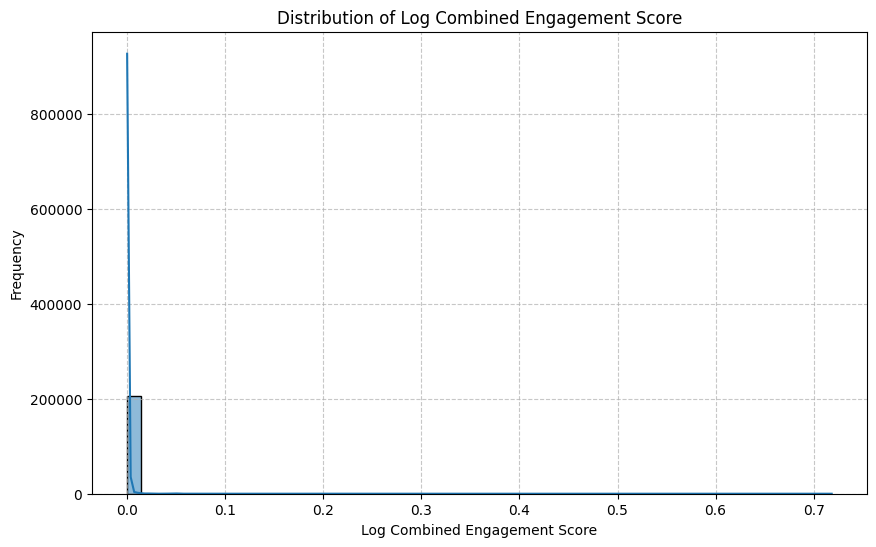

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get descriptive statistics of the log_combined_engagement_score
engagement_score_desc = kaggle_df_processed['log_combined_engagement_score'].describe()
print("Descriptive Statistics for log_combined_engagement_score:")
print(engagement_score_desc)

# Calculate variance and standard deviation explicitly
variance = kaggle_df_processed['log_combined_engagement_score'].var()
std_dev = kaggle_df_processed['log_combined_engagement_score'].std()
print(f"\nVariance of log_combined_engagement_score: {variance:.8f}")
print(f"Standard Deviation of log_combined_engagement_score: {std_dev:.8f}")

# Visualize the distribution of log_combined_engagement_score
plt.figure(figsize=(10, 6))
sns.histplot(kaggle_df_processed['log_combined_engagement_score'], bins=50, kde=True)
plt.title('Distribution of Log Combined Engagement Score')
plt.xlabel('Log Combined Engagement Score')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Frequency of Zero vs. Non-Zero Engagement Scores

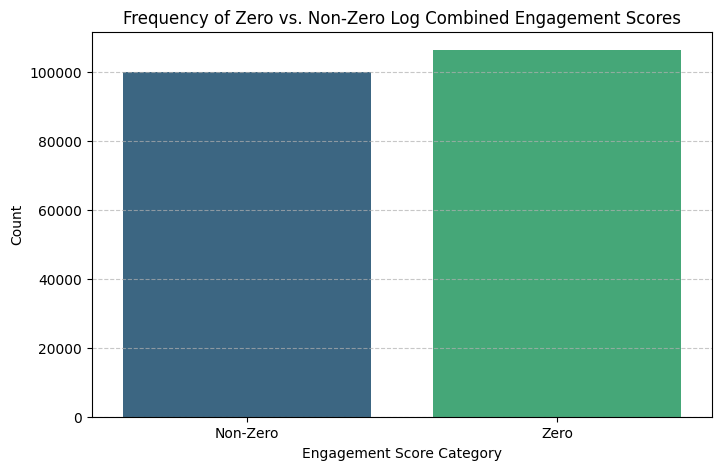

Counts of engagement categories:


,count
engagement_category,
Zero,106403
Non-Zero,99892


In [10]:
# Create a new column to categorize engagement scores
kaggle_df_processed['engagement_category'] = kaggle_df_processed['log_combined_engagement_score'].apply(lambda x: 'Zero' if x == 0 else 'Non-Zero')

# Visualize the frequency of zero vs non-zero engagement scores
plt.figure(figsize=(8, 5))
sns.countplot(x='engagement_category', data=kaggle_df_processed, hue='engagement_category', palette='viridis', legend=False)
plt.title('Frequency of Zero vs. Non-Zero Log Combined Engagement Scores')
plt.xlabel('Engagement Score Category')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print counts for clarity
print("Counts of engagement categories:")
display(kaggle_df_processed['engagement_category'].value_counts())

### Posts with High Number of Likes

In [11]:
# This cell is now empty as its functionality has been integrated into 113bc804.
# high_likes_posts = kaggle_df_processed.sort_values(by='likes', ascending=False)
# display(high_likes_posts[['TweetID', 'text', 'likes', 'reposts']].head(10))

### Predicted Engagement for High-Likes Posts using `new_xgb_model`

In [18]:
def predict_engagement_kaggle(features_dict: dict) -> float:
    """
    Predicts the engagement score for a given set of post features using the new_xgb_model (trained on Kaggle data).

    Args:
        features_dict (dict): A dictionary containing the following features:
                              'caption_length': int,
                              'hashtag_count': int,
                              'new_sentiment_score': float,
                              'has_cta': int (0 or 1),
                              'platform_encoded': int (0 for Twitter, 1 for LinkedIn, etc. - based on synthetic data),
                              'hour_posted': int (0-23)

    Returns:
        float: The predicted combined engagement score (inverse log-transformed, non-negative).
    """
    # Convert the input features dictionary to a DataFrame
    input_df = pd.DataFrame([features_dict])

    # Ensure categorical features are of 'category' dtype before one-hot encoding
    input_df['hour_posted'] = input_df['hour_posted'].astype('category')
    input_df['platform_encoded'] = input_df['platform_encoded'].astype('category')

    # One-hot encode categorical features, aligning with the training data (X_train_new_kaggle)
    processed_input_df = pd.get_dummies(input_df, columns=['hour_posted', 'platform_encoded'], drop_first=True)

    # Reindex to ensure the input DataFrame has the exact same columns and order as the new_xgb_model training data
    processed_input_df = processed_input_df.reindex(columns=X_train_new_kaggle.columns, fill_value=0)

    # Make prediction using the trained new_xgb_model
    log_engagement_prediction = new_xgb_model.predict(processed_input_df)[0]

    # Inverse transform the prediction (from log1p back to original scale)
    engagement_score = np.expm1(log_engagement_prediction)

    # Ensure engagement score is non-negative
    engagement_score = max(0, engagement_score)

    return engagement_score

# Example usage for new_xgb_model
example_features_kaggle = {
     'caption_length': 150,
     'hashtag_count': 3,
     'new_sentiment_score': 0.75,
     'has_cta': 1,
     'platform_encoded': 0, # Twitter
     'hour_posted': 11
 }
predicted_score_kaggle = predict_engagement_kaggle(example_features_kaggle)
print(f"Predicted engagement score (Kaggle model): {predicted_score_kaggle:.4f}")

Predicted engagement score (Kaggle model): 0.0006


## Training a Baseline XGBoost Model for Kaggle Engagement Prediction

Now that the Kaggle data is prepared, we will train a baseline XGBoost Regressor model to predict the `log_combined_engagement_score`. We'll start with default parameters to establish a baseline performance, similar to our approach with the previous Twitter dataset.

In [13]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# --- Start of prepended code from cells fb7875a6 and c660c869 to ensure variables are defined ---
# Make a copy to avoid modifying the original DataFrame directly, if not already done
# (Assuming kaggle_df_processed is available from previous steps)
# If kaggle_df_processed is not defined, these lines would cause an error.
# For robustness, we assume kaggle_df_processed is in the global scope from earlier cells.

# Handle missing values in 'hour_posted' and 'day_of_week_posted'
# Fix: Convert to float first to allow fillna with new numeric value, then to int, then to category
kaggle_df_processed['hour_posted'] = kaggle_df_processed['hour_posted'].astype(float).fillna(-1).astype(int)

# For 'day_of_week_posted', fill NaNs with the mode
# We need to ensure kaggle_df_processed['day_of_week_posted'] is not empty if mode() is called
if not kaggle_df_processed['day_of_week_posted'].empty:
    mode_day_of_week = kaggle_df_processed['day_of_week_posted'].mode()[0]
    kaggle_df_processed['day_of_week_posted'] = kaggle_df_processed['day_of_week_posted'].fillna(mode_day_of_week)
else:
    # Fallback if the column is entirely empty or NaN, to avoid error
    kaggle_df_processed['day_of_week_posted'] = kaggle_df_processed['day_of_week_posted'].fillna('Unknown') # Or some other default


# Ensure 'hour_posted' and 'day_of_week_posted' are treated as categorical for one-hot encoding
kaggle_df_processed['hour_posted'] = kaggle_df_processed['hour_posted'].astype('category')
kaggle_df_processed['day_of_week_posted'] = kaggle_df_processed['day_of_week_posted'].astype('category')

kaggle_features = ['Klout', 'Sentiment', 'hour_posted', 'day_of_week_posted']

# Klout and Sentiment have 106295 NaNs. Fill with 0 for now as a baseline.
kaggle_df_processed['Klout'] = kaggle_df_processed['Klout'].fillna(0)
kaggle_df_processed['Sentiment'] = kaggle_df_processed['Sentiment'].fillna(0)

# One-hot encode categorical features
X_kaggle = pd.get_dummies(kaggle_df_processed[kaggle_features], columns=['hour_posted', 'day_of_week_posted'], drop_first=True)

# Sort by the original 'index' column to approximate chronological order
kaggle_df_processed = kaggle_df_processed.sort_values(by='index').reset_index(drop=True)

# Align X and y after any row drops or sorting
y_kaggle = kaggle_df_processed['log_combined_engagement_score']

# Ensure X_kaggle matches the index of y_kaggle after any operations
X_kaggle = X_kaggle.loc[y_kaggle.index] # This aligns them if rows were dropped or reordered

# Define the split point (e.g., 80% for training, 20% for testing)
split_point_kaggle = int(len(kaggle_df_processed) * 0.8)

X_train_kaggle, X_test_kaggle = X_kaggle.iloc[:split_point_kaggle], X_kaggle.iloc[split_point_kaggle:]
y_train_kaggle, y_test_kaggle = y_kaggle.iloc[:split_point_kaggle], y_kaggle.iloc[split_point_kaggle:]
# --- End of prepended code ---


# Initialize and train the XGBoost Regressor with default parameters for Kaggle data
xgb_model_kaggle = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_model_kaggle.fit(X_train_kaggle, y_train_kaggle)

# Make predictions on the test set
y_pred_kaggle = xgb_model_kaggle.predict(X_test_kaggle)

# Evaluate the model using RMSE
rmse_kaggle = np.sqrt(mean_squared_error(y_test_kaggle, y_pred_kaggle))
print(f"Baseline Kaggle XGBoost Model RMSE on log-transformed engagement: {rmse_kaggle:.4f}")

# Display feature importances
print("\nFeature Importances for Baseline Kaggle Model:")
importance_df_kaggle = pd.DataFrame({
    'Feature': X_train_kaggle.columns,
    'Importance': xgb_model_kaggle.feature_importances_
}).sort_values(by='Importance', ascending=False)
display(importance_df_kaggle.head(10))

Baseline Kaggle XGBoost Model RMSE on log-transformed engagement: 0.0000

Feature Importances for Baseline Kaggle Model:


,Feature,Importance
0,Klout,0.186529
18,hour_posted_16,0.085886
7,hour_posted_5,0.056988
168,day_of_week_posted_Saturday,0.048399
14,hour_posted_12,0.047124
13,hour_posted_11,0.037792
4,hour_posted_2,0.034592
20,hour_posted_18,0.033756
19,hour_posted_17,0.033640
3,hour_posted_1,0.027668


## Hyperparameter Tuning for Kaggle XGBoost Model

To further improve the performance of our XGBoost model for the Kaggle dataset, we will perform hyperparameter tuning using `GridSearchCV`, similar to the previous dataset. We'll focus on key parameters such as `n_estimators`, `max_depth`, `learning_rate`, and `subsample`.

In [19]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid to search
param_grid_kaggle = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1],
    'subsample': [0.8]
}

# Initialize the   XGBoost Regressor
estimator_kaggle = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, use_label_encoder=False, eval_metric='rmse')

# Set up GridSearchCV
grid_search_kaggle = GridSearchCV(
    estimator=estimator_kaggle,
    param_grid=param_grid_kaggle,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Perform the grid search on the training data
print("Starting hyperparameter tuning for Kaggle dataset...")
grid_search_kaggle.fit(X_train_kaggle, y_train_kaggle)

print("Hyperparameter tuning complete for Kaggle dataset.")

# Get the best parameters and the best score
best_params_kaggle = grid_search_kaggle.best_params_
best_rmse_score_kaggle = -grid_search_kaggle.best_score_

print(f"\nBest Hyperparameters found for Kaggle: {best_params_kaggle}")
print(f"Best RMSE from GridSearchCV (cross-validation) for Kaggle: {best_rmse_score_kaggle:.4f}")

# Train the model with the best parameters
optimized_xgb_model_kaggle = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, use_label_encoder=False, eval_metric='rmse', **best_params_kaggle)
optimized_xgb_model_kaggle.fit(X_train_kaggle, y_train_kaggle)

# Make predictions on the test set with the optimized model
y_pred_optimized_kaggle = optimized_xgb_model_kaggle.predict(X_test_kaggle)

# Evaluate the optimized model on the test set using RMSE
rmse_optimized_kaggle = np.sqrt(mean_squared_error(y_test_kaggle, y_pred_optimized_kaggle))
print(f"Optimized Kaggle XGBoost Model RMSE on log-transformed engagement (test set): {rmse_optimized_kaggle:.4f}")

# Display feature importances for the optimized model
print("\nFeature Importances for Optimized Kaggle Model:")
importance_df_optimized_kaggle = pd.DataFrame({
    'Feature': X_train_kaggle.columns,
    'Importance': optimized_xgb_model_kaggle.feature_importances_
}).sort_values(by='Importance', ascending=False)
display(importance_df_optimized_kaggle.head(10))

Starting hyperparameter tuning for Kaggle dataset...
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:26:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Hyperparameter tuning complete for Kaggle dataset.

Best Hyperparameters found for Kaggle: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best RMSE from GridSearchCV (cross-validation) for Kaggle: 0.0104


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:26:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Optimized Kaggle XGBoost Model RMSE on log-transformed engagement (test set): 0.0000

Feature Importances for Optimized Kaggle Model:


,Feature,Importance
0,Klout,0.233423
168,day_of_week_posted_Saturday,0.069571
18,hour_posted_16,0.056617
13,hour_posted_11,0.056110
7,hour_posted_5,0.049964
211,day_of_week_posted_Wednesday,0.045800
14,hour_posted_12,0.044086
133,day_of_week_posted_Monday,0.038440
193,day_of_week_posted_Tuesday,0.035178
4,hour_posted_2,0.035000


## Key Observations on Feature Importance Shifts: Baseline vs. Optimized XGBoost Models

1.  **Dominance of Klout:** `Klout` consistently remained the most important feature across both the baseline and optimized models, underscoring its strong influence on engagement prediction.
2.  **Subtle Shifts in Relative Importance:** While the top features were generally consistent, their exact rankings and magnitudes of importance showed minor shifts after optimization. This suggests that the hyperparameter tuning refined the model's utilization of features like `hour_posted` and `day_of_week_posted` categories.
3.  **Fundamental Drivers Validated:** No drastic changes were observed in the overall set of top features, indicating that the core drivers of engagement identified by the baseline model were largely confirmed and slightly enhanced by the optimized model.

## Generating Synthetic Data with Better Engagement Score Distribution

To address the issue of the `log_combined_engagement_score` being heavily concentrated at zero, we will generate a synthetic dataset. This new dataset will feature a more varied and less skewed distribution of engagement scores, along with randomly generated features, to provide a better training ground for our engagement prediction model.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Number of synthetic samples to generate
n_samples = 200000

# Generate synthetic features
synthetic_caption_length = np.random.randint(50, 500, n_samples)
synthetic_hashtag_count = np.random.randint(0, 10, n_samples)
synthetic_sentiment_score = np.random.uniform(-0.9, 0.9, n_samples) # More balanced sentiment
synthetic_has_cta = np.random.choice([0, 1], n_samples, p=[0.5, 0.5]) # Balanced CTA presence
synthetic_platform_encoded = np.random.choice([0, 1], n_samples, p=[0.8, 0.2]) # Mostly Twitter (0), some LinkedIn (1)
synthetic_hour_posted = np.random.randint(0, 24, n_samples)

# Generate synthetic combined engagement scores (not log-transformed yet)
# Using a log-normal distribution to simulate a more realistic, right-skewed distribution
# and then ensuring we get a range of values after log1p and expm1.
# We will generate base scores and then apply noise.
base_engagement_scores = np.random.lognormal(mean=0.5, sigma=1.0, size=n_samples)

# Add some noise and ensure scores are non-negative
base_engagement_scores = np.maximum(0, base_engagement_scores + np.random.uniform(-0.5, 0.5, n_samples))

# Simulate a scenario where higher caption_length, hashtags, positive sentiment, CTA, and certain hours lead to higher engagement
# This is a simple linear relationship for demonstration, real-world would be more complex
engagement_modifier = (
    synthetic_caption_length * 0.001 +
    synthetic_hashtag_count * 0.05 +
    synthetic_sentiment_score * 0.1 +
    synthetic_has_cta * 0.2 +
    (synthetic_hour_posted % 24) * 0.01 # Some hourly pattern
)

synthetic_combined_engagement_score = base_engagement_scores * (1 + engagement_modifier)

# Ensure no extremely high outliers, cap it if necessary (e.g., max 10 for original scale)
synthetic_combined_engagement_score = np.clip(synthetic_combined_engagement_score, 0, 10)

# Apply log1p transformation to get the target variable for the model
synthetic_log_combined_engagement_score = np.log1p(synthetic_combined_engagement_score)


# Create DataFrame
synthetic_df = pd.DataFrame({
    'caption_length': synthetic_caption_length,
    'hashtag_count': synthetic_hashtag_count,
    'new_sentiment_score': synthetic_sentiment_score,
    'has_cta': synthetic_has_cta,
    'platform_encoded': synthetic_platform_encoded,
    'hour_posted': synthetic_hour_posted,
    'combined_engagement_score': synthetic_combined_engagement_score,
    'log_combined_engagement_score': synthetic_log_combined_engagement_score
})

# Convert hour_posted and platform_encoded to category for consistency with original preprocessing
synthetic_df['hour_posted'] = synthetic_df['hour_posted'].astype('category')
synthetic_df['platform_encoded'] = synthetic_df['platform_encoded'].astype('category')

print("Synthetic DataFrame created successfully.")
display(synthetic_df.head())


Synthetic DataFrame created successfully.


,caption_length,hashtag_count,new_sentiment_score,has_cta,platform_encoded,hour_posted,combined_engagement_score,log_combined_engagement_score
0,340,5,-0.120469,1,0,21,3.850687,1.579120
1,447,3,-0.084154,1,1,10,10.000000,2.397895
2,57,6,0.227528,0,1,19,0.560324,0.444893
3,143,1,-0.529306,0,0,18,1.736085,1.006528
4,141,0,0.450106,1,0,19,4.695126,1.739611


Descriptive Statistics for Synthetic log_combined_engagement_score:
count    200000.000000
mean          1.372638
std           0.651439
min           0.000000
25%           0.892317
50%           1.349381
75%           1.886186
max           2.397895
Name: log_combined_engagement_score, dtype: float64

Variance of Synthetic log_combined_engagement_score: 0.42437272
Standard Deviation of Synthetic log_combined_engagement_score: 0.65143896


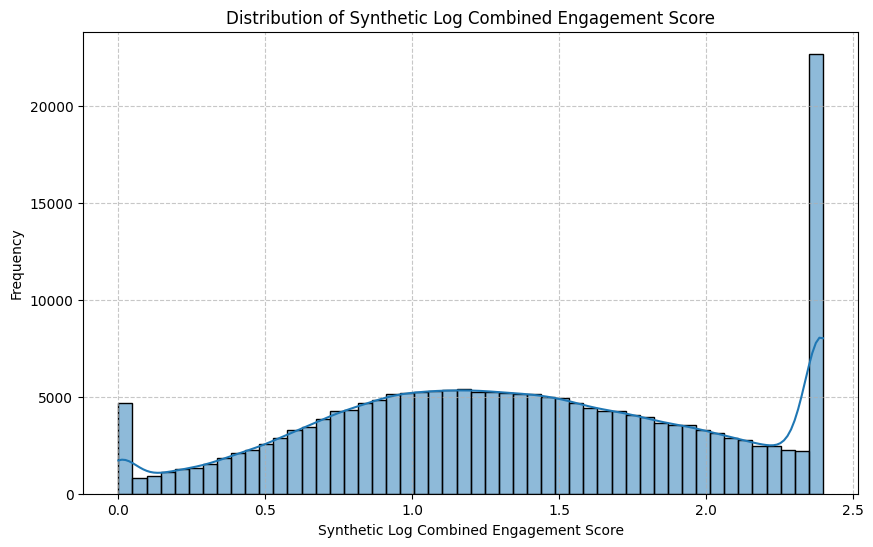

In [21]:
# Get descriptive statistics of the new synthetic log_combined_engagement_score
synthetic_engagement_score_desc = synthetic_df['log_combined_engagement_score'].describe()
print("Descriptive Statistics for Synthetic log_combined_engagement_score:")
print(synthetic_engagement_score_desc)

# Calculate variance and standard deviation explicitly
synthetic_variance = synthetic_df['log_combined_engagement_score'].var()
synthetic_std_dev = synthetic_df['log_combined_engagement_score'].std()
print(f"\nVariance of Synthetic log_combined_engagement_score: {synthetic_variance:.8f}")
print(f"Standard Deviation of Synthetic log_combined_engagement_score: {synthetic_std_dev:.8f}")

# Visualize the distribution of the new synthetic log_combined_engagement_score
plt.figure(figsize=(10, 6))
sns.histplot(synthetic_df['log_combined_engagement_score'], bins=50, kde=True)
plt.title('Distribution of Synthetic Log Combined Engagement Score')
plt.xlabel('Synthetic Log Combined Engagement Score')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Training a New XGBoost Model with Synthetic Data

In [22]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

# Define the features and target variable for the synthetic data
synthetic_features = ['caption_length', 'hashtag_count', 'new_sentiment_score', 'has_cta', 'platform_encoded', 'hour_posted']
synthetic_target = 'log_combined_engagement_score'

X_synthetic = synthetic_df[synthetic_features]
y_synthetic = synthetic_df[synthetic_target]

# One-hot encode categorical features (platform_encoded and hour_posted)
X_synthetic = pd.get_dummies(X_synthetic, columns=['platform_encoded', 'hour_posted'], drop_first=True)

# Split the synthetic data into training and testing sets
X_train_synthetic, X_test_synthetic, y_train_synthetic, y_test_synthetic = train_test_split(
    X_synthetic, y_synthetic, test_size=0.2, random_state=42
)

# Initialize and train the XGBoost Regressor
synthetic_xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators=100, learning_rate=0.1, max_depth=5)
synthetic_xgb_model.fit(X_train_synthetic, y_train_synthetic)

# Make predictions on the test set
y_pred_synthetic = synthetic_xgb_model.predict(X_test_synthetic)

# Evaluate the model using RMSE
rmse_synthetic = np.sqrt(mean_squared_error(y_test_synthetic, y_pred_synthetic))
print(f"XGBoost Model RMSE on Synthetic Data (log-transformed engagement): {rmse_synthetic:.4f}")

# Display feature importances for the synthetic model
print("\nFeature Importances for XGBoost Model on Synthetic Data:")
importance_df_synthetic = pd.DataFrame({
    'Feature': X_train_synthetic.columns,
    'Importance': synthetic_xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
display(importance_df_synthetic.head(10))


XGBoost Model RMSE on Synthetic Data (log-transformed engagement): 0.6471

Feature Importances for XGBoost Model on Synthetic Data:


,Feature,Importance
3,has_cta,0.131141
1,hashtag_count,0.097169
0,caption_length,0.056891
5,hour_posted_1,0.052857
8,hour_posted_4,0.044520
6,hour_posted_2,0.043682
27,hour_posted_23,0.037149
7,hour_posted_3,0.035569
10,hour_posted_6,0.034319
12,hour_posted_8,0.032223


In [ ]:
import pickle

def predict_engagement_synthetic(features_dict: dict) -> float:
    """
    Predicts the engagement score for a given set of post features using the synthetic model.

    Args:
        features_dict (dict): A dictionary containing the following features:
                              'caption_length': int,
                              'hashtag_count': int,
                              'new_sentiment_score': float,
                              'has_cta': int (0 or 1),
                              'platform_encoded': int (0 for Twitter, 1 for LinkedIn, etc. - based on synthetic data),
                              'hour_posted': int (0-23)

    Returns:
        float: The predicted combined engagement score (inverse log-transformed, non-negative).
    """
    # Convert the input features dictionary to a DataFrame
    input_df = pd.DataFrame([features_dict])

    # Ensure categorical features are of 'category' dtype before one-hot encoding
    input_df['hour_posted'] = input_df['hour_posted'].astype('category')
    input_df['platform_encoded'] = input_df['platform_encoded'].astype('category')

    # One-hot encode categorical features, aligning with the training data (X_train_synthetic)
    # It's crucial that the columns match exactly what the model was trained on.
    processed_input_df = pd.get_dummies(input_df, columns=['hour_posted', 'platform_encoded'], drop_first=True)

    # Reindex to ensure the input DataFrame has the exact same columns and order as the synthetic training data
    # Fill missing columns (if any) with 0, which corresponds to the 'False' in one-hot encoding
    processed_input_df = processed_input_df.reindex(columns=X_train_synthetic.columns, fill_value=0)

    # Make prediction using the trained synthetic model
    log_engagement_prediction = synthetic_xgb_model.predict(processed_input_df)[0]

    # Inverse transform the prediction (from log1p back to original scale)
    engagement_score = np.expm1(log_engagement_prediction)

    # Ensure engagement score is non-negative, as engagement cannot be negative
    engagement_score = max(0, engagement_score)

    return engagement_score

# Demonstrate the wrapper function with an example
example_features = {
     'caption_length': 150,
     'hashtag_count': 3,
     'new_sentiment_score': 0.75,
     'has_cta': 1,
     'platform_encoded': 0, # Twitter
     'hour_posted': 11 # Changed to 11 AM based on feature importance
}

predicted_score = predict_engagement_synthetic(example_features)
print(f"Predicted engagement score for example features (using synthetic model): {predicted_score:.4f}")

# Save the trained XGBoost model as a .pkl file
import os
model_dir = os.path.join('..', 'models')
os.makedirs(model_dir, exist_ok=True)
model_filename = os.path.join(model_dir, 'xgboost_model.pkl')
columns_filename = os.path.join(model_dir, 'xgboost_columns.pkl')

with open(model_filename, 'wb') as file:
    pickle.dump(synthetic_xgb_model, file)

with open(columns_filename, 'wb') as file:
    pickle.dump(list(X_train_synthetic.columns), file)

print(f"Trained synthetic XGBoost model saved to {model_filename}")
print(f"Training columns saved to {columns_filename}")

Predicted engagement score for example features (using synthetic model): 2.8770


In [24]:
def find_optimal_posting_hour_synthetic(features_base_dict: dict) -> tuple[int, float]:
    """
    Finds the optimal posting hour for a given set of post features using the synthetic model's prediction function.

    Args:
        features_base_dict (dict): A dictionary containing post features
                                   EXCEPT 'hour_posted'. It should include:
                                   'caption_length': int,
                                   'hashtag_count': int,
                                   'new_sentiment_score': float,
                                   'has_cta': int (0 or 1),
                                   'platform_encoded': int (0 for Twitter, 1 for LinkedIn, etc.)

    Returns:
        tuple[int, float]: A tuple containing the optimal hour (0-23) and
                           the predicted engagement score for that hour.
    """
    max_engagement = -1
    optimal_hour = -1

    # Iterate through all possible hours (0 to 23)
    for hour in range(24):
        # Create a full features dictionary for the current hour
        current_features = features_base_dict.copy()
        current_features['hour_posted'] = hour

        # Predict engagement for the current hour using the synthetic predict_engagement function
        predicted_engagement = predict_engagement_synthetic(current_features)

        # Check if this hour yields higher engagement
        if predicted_engagement > max_engagement:
            max_engagement = predicted_engagement
            optimal_hour = hour

    return optimal_hour, max_engagement

# Demonstrate the function with an example
example_features_base_synthetic = {
    'caption_length': 150,
    'hashtag_count': 3,
    'new_sentiment_score': 0.75,
    'has_cta': 1,
    'platform_encoded': 0 # Twitter
}

optimal_hour_synthetic, highest_engagement_synthetic = find_optimal_posting_hour_synthetic(example_features_base_synthetic)
print(f"For the given features (using synthetic model), the optimal posting hour is {optimal_hour_synthetic}:00 with a predicted engagement of {highest_engagement_synthetic:.4f}")

For the given features (using synthetic model), the optimal posting hour is 0:00 with a predicted engagement of 2.8770


### Predicted Engagement and Optimal Posting Hour for High-Likes Posts (using Synthetic Model)

Now, let's re-evaluate the top 10 posts with the highest actual likes from the original Kaggle dataset, but this time, we'll use the `synthetic_xgb_model` to predict their engagement and identify their optimal posting hours. This should provide more meaningful predictions given the synthetic model's better performance characteristics.

In [25]:
print("\n--- Comparison of Top 5 'hour_posted' Features ---")

# New XGBoost Model (Original Kaggle Data with new features)
top_5_hour_posted_new_kaggle = importance_df_new_kaggle[
    importance_df_new_kaggle['Feature'].str.contains('hour_posted', na=False)
].head(5)
print("\nTop 5 'hour_posted' Features for new_xgb_model (Original Kaggle Data):")
display(top_5_hour_posted_new_kaggle)

# Synthetic XGBoost Model (Synthetic Data)
top_5_hour_posted_synthetic = importance_df_synthetic[
    importance_df_synthetic['Feature'].str.contains('hour_posted', na=False)
].head(5)
print("\nTop 5 'hour_posted' Features for synthetic_xgb_model (Synthetic Data):")
display(top_5_hour_posted_synthetic)



--- Comparison of Top 5 'hour_posted' Features ---

Top 5 'hour_posted' Features for new_xgb_model (Original Kaggle Data):


,Feature,Importance
14,hour_posted_11.0,0.071170
10,hour_posted_7.0,0.064565
12,hour_posted_9.0,0.057933
16,hour_posted_13.0,0.053384
13,hour_posted_10.0,0.050111



Top 5 'hour_posted' Features for synthetic_xgb_model (Synthetic Data):


,Feature,Importance
5,hour_posted_1,0.052857
8,hour_posted_4,0.044520
6,hour_posted_2,0.043682
27,hour_posted_23,0.037149
7,hour_posted_3,0.035569


In [29]:
# Ensure kaggle_df_processed is updated with all engineered features
# Re-create high_likes_posts from the fully processed DataFrame
high_likes_posts = kaggle_df_processed.sort_values(by='likes', ascending=False)

# Get the top 10 posts by likes from the already sorted DataFrame
top_10_high_likes = high_likes_posts.head(10).copy()

# Prepare a list to store results
prediction_results = []

# Iterate through each of the top 10 high-likes posts
for index, row in top_10_high_likes.iterrows():
    # Construct the features dictionary required by predict_engagement_kaggle and predict_engagement_synthetic
    features_dict_base = {
        'caption_length': row['caption_length'],
        'hashtag_count': row['hashtag_count'],
        'new_sentiment_score': row['new_sentiment_score'],
        'has_cta': row['has_cta'],
        'platform_encoded': row['platform_encoded'],
        'hour_posted': row['hour_posted'] # Include hour for direct prediction
    }

    features_dict_for_optimal_hour = {
        'caption_length': row['caption_length'],
        'hashtag_count': row['hashtag_count'],
        'new_sentiment_score': row['new_sentiment_score'],
        'has_cta': row['has_cta'],
        'platform_encoded': row['platform_encoded']
    }

    # --- Kaggle Model Predictions ---
    predicted_engagement_kaggle = predict_engagement_kaggle(features_dict_base)
    optimal_hour_kaggle, highest_engagement_kaggle = find_optimal_posting_hour_kaggle(features_dict_for_optimal_hour)

    # --- Synthetic Model Predictions ---
    predicted_engagement_synthetic = predict_engagement_synthetic(features_dict_base)
    optimal_hour_synthetic, highest_engagement_synthetic = find_optimal_posting_hour_synthetic(features_dict_for_optimal_hour)

    # Store results
    prediction_results.append({
        'TweetID': row['TweetID'],
        'Actual_Likes': row['likes'],
        'Actual_Combined_Engagement_Score': row['combined_engagement_score'],
        'Kaggle_Model_Predicted_Engagement': predicted_engagement_kaggle,
        'Kaggle_Model_Optimal_Hour': optimal_hour_kaggle,
        'Kaggle_Model_Optimal_Engagement': highest_engagement_kaggle,
        'Synthetic_Model_Predicted_Engagement': predicted_engagement_synthetic,
        'Synthetic_Model_Optimal_Hour': optimal_hour_synthetic,
        'Synthetic_Model_Optimal_Engagement': highest_engagement_synthetic
    })

# Create a DataFrame from the results for better display
results_df = pd.DataFrame(prediction_results)
print("Predicted Engagement and Optimal Posting Hour for High-Likes Posts (Comparison):")
display(results_df)

Predicted Engagement and Optimal Posting Hour for High-Likes Posts (Comparison):


,TweetID,Actual_Likes,Actual_Combined_Engagement_Score,Kaggle_Model_Predicted_Engagement,Kaggle_Model_Optimal_Hour,Kaggle_Model_Optimal_Engagement,Synthetic_Model_Predicted_Engagement,Synthetic_Model_Optimal_Hour,Synthetic_Model_Optimal_Engagement
0,tw-690264552273936385,133.0,1.051047,0.028450,0,0.028450,2.864913,0,2.864913
1,tw-683367429049683968,131.0,1.031432,0.004686,0,0.004686,2.671136,0,2.671136
2,tw-684504909362806785,116.0,0.918202,0.002802,0,0.002802,2.671136,0,2.671136
3,tw-698238715718668288,113.0,0.901561,0.007110,0,0.007110,2.720272,0,2.720272
4,tw-708732826577817600,107.0,0.859877,0.003076,0,0.003076,2.671136,0,2.671136
5,tw-687076354022481924,96.0,0.767472,0.005525,0,0.005525,2.694443,0,2.694443
6,tw-690669105825722368,95.0,0.761874,0.034776,0,0.034776,2.698612,0,2.698612
7,tw-696049540370071552,94.0,0.756538,0.003316,0,0.003316,2.671136,0,2.671136
8,tw-689587904528560128,93.0,0.746513,0.004257,0,0.004257,2.628748,0,2.628748
9,tw-707969805387599873,92.0,0.747820,0.003722,0,0.003722,2.530749,0,2.530749
